# TinyChirp SincNet-Time TensorFlow

Train a **Conv2D** model (`kernel_size=(k, 1)`) with a SincNet-style learnable frontend on raw audio (time runs along the spatial **height** dimension), export an int8 TFLite model, and write a Rust `audio_sample.rs` file.

This mirrors `building_tensorflow/cnn_time.ipynb` but replaces the first convolutional layer with a custom Sinc-like frontend whose learned filters are baked into a static `Conv2D` for inference. Rank-4 tensors throughout keep the graph compatible with microflow on device.

In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import tensorflow as tf

from utils import (
    TARGET_AUDIO_LEN_TIME,
    SAMPLE_RATE,
    get_paths,
    configure_tf_runtime,
    set_global_seed,
    make_time_datasets,
    build_representative_batches,
    export_keras_model_to_int8_tflite,
)

configure_tf_runtime()
set_global_seed()

MODEL_STEM = "sincnet_real_multilayer_tf"
paths = get_paths(MODEL_STEM)
OUT_TFLITE = paths.out_tflite
BATCH_SIZE = 32


In [15]:
def _time_nhwc(audio, label):
    """[B, T, 1] from utils -> [B, T, 1, 1] for Conv2D (time = height)."""
    return tf.expand_dims(audio, -1), label


train_ds, val_ds, test_ds, label_names = make_time_datasets()
train_ds = train_ds.map(_time_nhwc)
val_ds = val_ds.map(_time_nhwc)
test_ds = test_ds.map(_time_nhwc)
num_labels = len(label_names)
print("Classes:", label_names)

Found 11292 files belonging to 2 classes.
Found 1380 files belonging to 2 classes.
Found 1393 files belonging to 2 classes.
Classes: ['non_target' 'target']


## SincNet-style learnable frontend

We define a simplified SincNet-style learnable filterbank as a custom Keras layer that operates directly on the raw waveform. The layer maintains trainable parameters that are passed through a `sin` nonlinearity to produce filters, which are then applied via a 1D convolution.

In [16]:
import tensorflow as tf
import numpy as np
import math
from utils import get_flops_native

class SincnetConv(tf.keras.layers.Layer):
    def __init__(self, num_filters: int, kernel_size: int, stride: int, sample_rate: int = 16000, **kwargs):
        super().__init__(**kwargs)
        self.num_filters = num_filters
        self.stride = stride
        self.sample_rate = sample_rate
        
        # SincNet requires an odd kernel size for symmetric filters
        self.kernel_size = kernel_size if kernel_size % 2 != 0 else kernel_size + 1

    def build(self, input_shape):
        # 1. Initialize frequencies on the Mel scale
        mel_min = 0.0
        mel_max = self._hz_to_mel(self.sample_rate / 2.0)
        mel_points = np.linspace(mel_min, mel_max, self.num_filters + 1)
        hz_points = self._mel_to_hz(mel_points)
        
        # Normalize frequencies by sample rate (so Nyquist is 0.5)
        f1_init = hz_points[:-1] / self.sample_rate
        band_init = np.diff(hz_points) / self.sample_rate

        # 2. Trainable parameters: low cutoff (f1) and bandwidth (band)
        self.f1 = self.add_weight(
            name='f1',
            shape=(self.num_filters,),
            initializer=tf.keras.initializers.Constant(f1_init),
            trainable=True
        )
        self.band = self.add_weight(
            name='band',
            shape=(self.num_filters,),
            initializer=tf.keras.initializers.Constant(band_init),
            trainable=True
        )

        # 3. Static time grid and Hamming window
        t = np.linspace(-(self.kernel_size // 2), self.kernel_size // 2, self.kernel_size)
        self.t = tf.constant(t, dtype=tf.float32)
        
        window = 0.54 - 0.46 * np.cos(2 * math.pi * np.arange(self.kernel_size) / (self.kernel_size - 1))
        self.window = tf.constant(window, dtype=tf.float32)

    def get_filters(self) -> tf.Tensor:
        # Abs ensures frequencies stay positive
        f1_safe = tf.math.abs(self.f1)
        f2_safe = f1_safe + tf.math.abs(self.band)
        
        f1_mat = tf.reshape(f1_safe, (1, -1))
        f2_mat = tf.reshape(f2_safe, (1, -1))
        t_mat = tf.reshape(self.t, (-1, 1))
        
        # Equation: [sin(2*pi*f2*t) - sin(2*pi*f1*t)] / (pi * t)
        pi_t = math.pi * t_mat
        
        # Prevent division by zero at t=0 by substituting 1.0 (we overwrite the center later)
        denom = tf.where(t_mat == 0.0, 1.0, pi_t)
        
        filters = (tf.math.sin(2.0 * math.pi * f2_mat * t_mat) - 
                   tf.math.sin(2.0 * math.pi * f1_mat * t_mat)) / denom
                   
        # The limit of the function as t approaches 0 is 2(f2 - f1)
        center_values = 2.0 * (f2_mat - f1_mat)
        
        # Inject the mathematical limit into the center index (t=0)
        mask = tf.cast(t_mat == 0.0, tf.float32)
        filters = filters * (1.0 - mask) + center_values * mask
        
        # Apply Hamming Window
        filters = filters * tf.reshape(self.window, (-1, 1))
        
        # Conv1D-style layout (k, in_ch, out_ch); we reshape to NHWC for conv2d.
        return tf.reshape(filters, (self.kernel_size, 1, self.num_filters))

    def get_filters_nhwc(self) -> tf.Tensor:
        """tf.nn.conv2d filter [k_h, k_w, in_c, out_c]."""
        f = self.get_filters()  # (k, 1, out_ch)
        return tf.reshape(f, (self.kernel_size, 1, 1, self.num_filters))

    def call(self, inputs: tf.Tensor) -> tf.Tensor:
        # inputs [batch, time, 1, 1] — time is height (see build_training_model)
        return tf.nn.conv2d(
            inputs,
            self.get_filters_nhwc(),
            strides=[1, self.stride, 1, 1],
            padding="VALID",
            data_format="NHWC",
        )

    def export_to_conv2d(self, name: str = "baked_sinc_conv") -> tf.keras.layers.Conv2D:
        """Bakes learned Sinc filters into a static Conv2D for TFLite / microflow."""
        baked = self.get_filters().numpy()
        w = np.reshape(baked, (self.kernel_size, 1, 1, self.num_filters))
        conv_layer = tf.keras.layers.Conv2D(
            filters=self.num_filters,
            kernel_size=(self.kernel_size, 1),
            strides=(self.stride, 1),
            padding="valid",
            use_bias=False,
            name=name,
        )
        conv_layer.build(input_shape=(None, None, 1, 1))
        conv_layer.set_weights([w])
        return conv_layer

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_filters": self.num_filters,
            "kernel_size": self.kernel_size,
            "stride": self.stride,
            "sample_rate": self.sample_rate,
        })
        return config

    # Mel-Scale DSP Helpers
    def _hz_to_mel(self, hz):
        return 2595.0 * np.log10(1.0 + hz / 700.0)
    
    def _mel_to_hz(self, mel):
        return 700.0 * (10.0**(mel / 2595.0) - 1.0)

In [17]:
SINCNET_FILTERS = 32
SINCNET_STRIDE = 32
SINCNET_KERNEL_SIZE = 64

CONV_FILTERS = 16
CONV_FILTER_SIZE = 8
CONV_STRIDE = 2

DENSE_HIDDEN = 64


def build_training_model(num_labels: int) -> tf.keras.Model:
    # NHWC: time = height, fixed width 1 — matches microflow rank-4 buffers.
    inputs = tf.keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1, 1))

    x = SincnetConv(
        num_filters=SINCNET_FILTERS,
        kernel_size=SINCNET_KERNEL_SIZE,
        stride=SINCNET_STRIDE,
        sample_rate=SAMPLE_RATE,
        name="sincnet_convolution",
    )(inputs)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.AveragePooling2D(pool_size=(4, 1), name="envelope_pool")(x)

    x = tf.keras.layers.Conv2D(
        filters=CONV_FILTERS,
        kernel_size=(CONV_FILTER_SIZE, 1),
        strides=(CONV_STRIDE, 1),
        padding="same",
        name="temporal_conv_1",
    )(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.AveragePooling2D(pool_size=(4, 1), name="temporal_pool_1")(x)

    x = tf.keras.layers.Conv2D(
        filters=CONV_FILTERS,
        kernel_size=(CONV_FILTER_SIZE, 1),
        strides=(CONV_STRIDE, 1),
        padding="same",
        name="temporal_conv_2",
    )(x)
    x = tf.keras.layers.ReLU()(x)

    # GlobalAveragePooling1D maps to MEAN in TFLite which microflow doesn't support.
    # AveragePooling2D maps to AVERAGE_POOL_2D — pool the full time (height) axis.
    x = tf.keras.layers.AveragePooling2D(
        pool_size=(x.shape[1], 1), padding="valid", name="final_pool"
    )(x)
    x = tf.keras.layers.Flatten(name="flatten")(x)

    x = tf.keras.layers.Dense(DENSE_HIDDEN, activation="relu", name="dense_hidden")(x)
    outputs = tf.keras.layers.Dense(num_labels, activation=None, name="dense_logits")(x)

    return tf.keras.Model(inputs, outputs, name="sincnet_training")

training_model = build_training_model(num_labels)
training_model.summary()

flops = get_flops_native(training_model, batch_size=1)
print(f"Total FLOPs: {flops}")

Model: "sincnet_training"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 47872, 1, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sincnet_convolution             │ (None, 1494, 1, 32)    │            64 │
│ (SincnetConv)                   │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 1494, 1, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ envelope_pool                   │ (None, 373, 1, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_conv_1 (Conv2D)        │ (None, 187, 1, 16)     │         4,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 187, 1, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_pool_1                 │ (None, 46, 1, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_conv_2 (Conv2D)        │ (None, 23, 1, 16)      │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 23, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_pool (AveragePooling2D)   │ (None, 1, 1, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_logits (Dense)            │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,458 (29.13 KB)

 Trainable params: 7,458 (29.13 KB)

 Non-trainable params: 0 (0.00 B)

Total FLOPs: 7914998


/home/nathan/Documents/tiny-chirp-microflow/building_tensorflow/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_41
Received: inputs=['Tensor(shape=(1, 47872, 1, 1))']
  warnings.warn(msg)
2026-04-20 10:57:02.810447: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-20 10:57:02.811429: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
2026-04-20 10:57:02.811541: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-04-20 10:57:02.811872: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successf

In [18]:
from utils import init_wandb, get_callbacks, finish_wandb

training_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

init_wandb(MODEL_STEM, config={
    "sincnet_num_filters": SINCNET_FILTERS,
    "sincnet_kernel_size": SINCNET_KERNEL_SIZE,
    "sincnet_stride": SINCNET_STRIDE,
    "conv_filters": CONV_FILTERS,
    "conv_filter_size": CONV_FILTER_SIZE,
    "conv_stride": CONV_STRIDE,
    "dense_hidden": DENSE_HIDDEN,
})

history = training_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    validation_steps=44,
    callbacks=get_callbacks(10,5,BATCH_SIZE)
)
finish_wandb()

Epoch 1/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step - accuracy: 0.8397 - loss: 0.3350 - val_accuracy: 0.9428 - val_loss: 0.1977
Epoch 2/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - accuracy: 0.9178 - loss: 0.2067 - val_accuracy: 0.9420 - val_loss: 0.1501
Epoch 3/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9363 - loss: 0.1742 - val_accuracy: 0.9464 - val_loss: 0.1436
Epoch 4/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.9427 - loss: 0.1554 - val_accuracy: 0.9580 - val_loss: 0.1256
Epoch 5/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.9498 - loss: 0.1320 - val_accuracy: 0.9587 - val_loss: 0.1189
Epoch 6/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9521 - loss: 0.1220 - val_accuracy: 0.9674 - val_loss: 0.1115
Epoch 7/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.9601 - loss: 0.1089 - val_accuracy: 0.9587 - val_loss: 0.1184
Epoch 8/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.9578 - loss: 0

batch/accuracy,▁▄▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇██▇▇▇▇█████▇███▇
batch/batch_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇████
batch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/loss,█▆▆▅▅▄▄▄▃▃▃▄▄▃▃▃▃▂▃▂▃▃▂▁▁▁▂▂▂▂▂▂▂▇▂▂▂▂▂▂
epoch/accuracy,▁▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇████████████████████
epoch/epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▁▂▃▄▅▄▄▄▂▄▆▅▆▆▅▇▆▆▆▇▆▇▇▇▇▅█▆▇▇▇▇▇▆▇▆▇
epoch/val_loss,█▆▅▅▄▄▄▄▄▆▃▃▃▃▂▂▂▂▂▃▁▂▂▁▁▁▃▁▂▁▁▂▁▁▂▂▂▁
+6,...


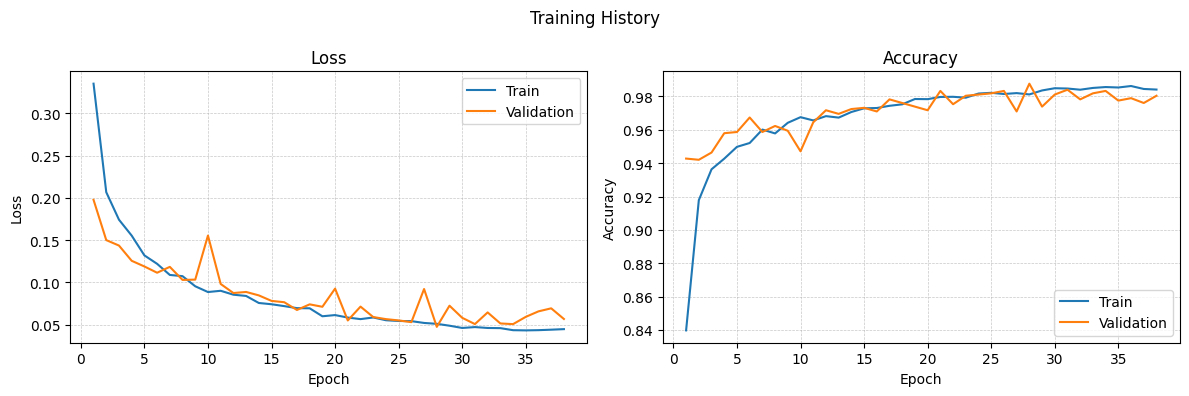

In [19]:
from utils import plot_training_history
plot_training_history(history)

## Make frontend filters into a Conv2D inference model


In [20]:
frontend_layer = training_model.get_layer("sincnet_convolution")
baked_conv_layer = frontend_layer.export_to_conv2d(name="baked_sinc_conv")

infer_inputs = tf.keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1, 1))
x = baked_conv_layer(infer_inputs)
x = tf.keras.layers.ReLU()(x)
x = training_model.get_layer("envelope_pool")(x)
x = training_model.get_layer("temporal_conv_1")(x)
x = tf.keras.layers.ReLU()(x)
x = training_model.get_layer("temporal_pool_1")(x)
x = training_model.get_layer("temporal_conv_2")(x)
x = tf.keras.layers.ReLU()(x)
x = training_model.get_layer("final_pool")(x)
x = training_model.get_layer("flatten")(x)
x = training_model.get_layer("dense_hidden")(x)
outputs = training_model.get_layer("dense_logits")(x)

inference_model = tf.keras.Model(infer_inputs, outputs, name="sincnet_inference")

for batch_audio, _ in test_ds.take(1):
    logits_train = training_model.predict(batch_audio.numpy(), verbose=0)
    logits_infer = inference_model.predict(batch_audio.numpy(), verbose=0)
    print(f"Max abs diff: {np.max(np.abs(logits_train - logits_infer)):.8f}")

Max abs diff: 0.00000000


2026-04-20 11:09:43.572322: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Export quantized TFLite model and Rust audio samples

We now export an int8-quantized TFLite model using the shared helpers from `building_tensorflow.utils`, and regenerate `audio_sample.rs` clips for the TinyChirp Rust runner.

In [21]:
rep_batches = build_representative_batches(test_ds, take=100)

try:
    export_keras_model_to_int8_tflite(inference_model, rep_batches, OUT_TFLITE)
    print(f"Success! Wrote {OUT_TFLITE}")
except Exception as e:
    print(f"TFLite conversion failed: {e}")

2026-04-20 11:09:44.103634: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Saved artifact at '/tmp/tmp33kvblbs'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 47872, 1, 1), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(1, 2), dtype=tf.float32, name=None)
Captures:
  136468338352272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136470553993008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136470553992832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136470553994240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136470553989312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136470553992304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136470553992128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136470553992656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136470553995120: TensorSpec(shape=(), dtype=tf.resource, name=None)
Success! Wrote /home/nathan/Documents/tiny-chirp-microflow/models/sincnet_real_multilayer_tf.tflite


W0000 00:00:1776676184.962144   33185 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1776676184.962163   33185 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-04-20 11:09:44.962356: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp33kvblbs
2026-04-20 11:09:44.963008: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 11:09:44.963021: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp33kvblbs
2026-04-20 11:09:44.970555: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-04-20 11:09:44.999082: I tensorflow/cc/saved_model/loader.cc:218] Running initialization op on SavedModel bundle at path: /tmp/tmp33kvblbs
2026-04-20 11:09:45.007637: I tensorflow/cc/saved_model/loader.cc:317] SavedModel load for tags { serve }; Status: success: OK. Took 45285 microseconds.
2026-04-20 11:09:45.051613: I tensorflow/comp

2026-04-20 11:10:05.135583: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Model size : 9.8 KB
Est. MFLOPs: 0.268
=== Binary classifier metrics : TEST SET===
Threshold: 0.3320  (best F2 threshold)
Accuracy : 0.9598
Precision: 0.9020
Recall   : 0.9847
F2 score : 0.9670
=== Binary classifier metrics : TRAIN SET===
AUC      : 0.9958


2026-04-20 11:10:07.620396: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


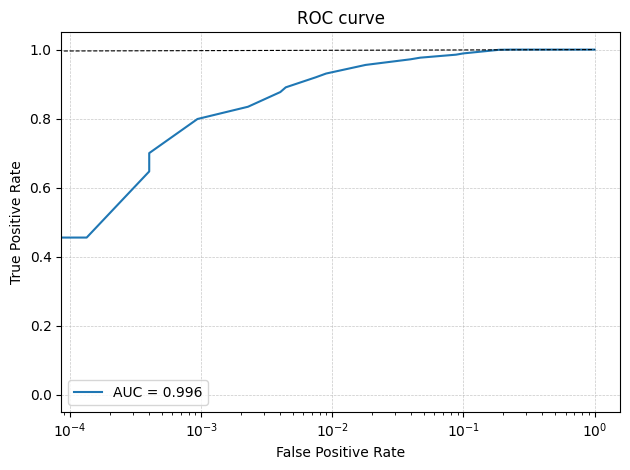

Avg inference: 1.204 ms


In [22]:
from utils import evaluate_tflite_model

train_m, test_m, avg_ms = evaluate_tflite_model(OUT_TFLITE, MODEL_STEM, train_ds, test_ds)
print(f"Avg inference: {avg_ms:.3f} ms")